In [2]:
import numpy as np
import pandas as pd

## Series is 1D and DataFrames are 2D objects of Pandas library
⚡ But why ?

Ans : Series are 1D coz they have only 1-dimensional data i.e. 'index' to fetch out any Data value but whereas in DataFrames, it is 2-dimensional data i.e. 'index' and 'any specific column' to fetch specific data value

⚡ And what exactly is index ?

Ans : An Index in pandas is a crucial component that uniquely identifies each element in a Series or each row in a DataFrame

## For Series:
A Series is a one-dimensional labeled array. Its index provides a label for each data point.

## For DataFrames:
A DataFrame is a two-dimensional labeled data structure with columns of potentially different types. It has two indices:

- Row Index (or just 'Index'): Labels for each row, similar to a Series index.

- Column Index: Labels for each column( say, column name )

## Multi-Indexing series also known as 'Hierarchical Indexing'
- We need to create multi-index object to make multi-index series

## Why Multi-Indexing ?

- Handles and represent higher-dimensional data within a '1D Series' or a '2D DataFrame'

In [3]:
# How to create Multi-index object

# 1- pd.MultiIndex.from_tuples()
index_val = [ ('cse' , 2019) , ('cse' , 2020) , ('cse' , 2021) , ('cse' , 2022) , ('ece' , 2019) , ('ece' , 2020) , ('ece' , 2021) , ('ece' , 2022) ]     # list of tuples
a = pd.MultiIndex.from_tuples(index_val)
print(a)            # 'a' is the multi-index object


# multi-index decouples all the indexes and provide lists of them separately
print(a.levels[0])
print(a.levels[1] , '\n')

# 2- pd.MultiIndex.from_product()
b = pd.MultiIndex.from_product([['cse' , 'ece'] , [2019 , 2020 , 2021 , 2022]])
print(b)

MultiIndex([('cse', 2019),
            ('cse', 2020),
            ('cse', 2021),
            ('cse', 2022),
            ('ece', 2019),
            ('ece', 2020),
            ('ece', 2021),
            ('ece', 2022)],
           )
Index(['cse', 'ece'], dtype='object')
Index([2019, 2020, 2021, 2022], dtype='int64') 

MultiIndex([('cse', 2019),
            ('cse', 2020),
            ('cse', 2021),
            ('cse', 2022),
            ('ece', 2019),
            ('ece', 2020),
            ('ece', 2021),
            ('ece', 2022)],
           )


In [4]:
# Creating a series multi-index object
s = pd.Series([1,2,3,4,5,6,7,8] , index = a)    # 'a' is multi-index object created above
print(s , '\n')


# fetching on first index (labelled index)
print(s.loc['cse'] , '\n')

# fetching on second index (integer index)
print(s.iloc[6])

cse  2019    1
     2020    2
     2021    3
     2022    4
ece  2019    5
     2020    6
     2021    7
     2022    8
dtype: int64 

2019    1
2020    2
2021    3
2022    4
dtype: int64 

7


## Converting Series into DataFrame and Vice-versa

In [5]:
# unstack() function : used to convert the multi-index series into a DataFrame ( Note : inner most 'index' will be taken as 'columns' for DataFrame )
temp = s.unstack()     # 's' is multi-index series above
display(temp)

# stack() function : used to convert DataFrames into multi-index series ( Note : 'columns' will be taken as innermost index for a multi-index series )
display(temp.stack())

,2019,2020,2021,2022
cse,1,2,3,4
ece,5,6,7,8


cse  2019    1
     2020    2
     2021    3
     2022    4
ece  2019    5
     2020    6
     2021    7
     2022    8
dtype: int64

## Multi-index 'DataFrame' from 'rows' persepective only ( 3-dimensional Data )

In [6]:
branch_df1 = pd.DataFrame(
    [
    [1,2],
    [3,4],
    [5,6],
    [7,8],
    [9,10],
    [11,12],
    [13,14],
    [15,16]
    ],
  index = a,
  columns = ['avg package' , 'students']
)

branch_df1       # multi-indexes as 'cse' and 'year'

avg package  students
cse 2019            1         2
    2020            3         4
    2021            5         6
    2022            7         8
ece 2019            9        10
    2020           11        12
    2021           13        14
    2022           15        16

In [7]:
# fetching data

print(branch_df1.loc['cse'] , '\n')                      # fetching 'cse' branch data for 'every year' with 'avg package and students'
print(branch_df1.iloc[2] , '\n')                         # fetching 2 index from the whole data i.e. 'cse' -> 2021 -> 'avg package and students'
print(branch_df1['avg package'] , '\n')                  # fetching 'avg package' column only
print(branch_df1['avg package'].loc['cse'])              # fetching 'avg' package for 'cse' index only
print(branch_df1['avg package'].loc['cse'].iloc[3])      # fetching 'avg' package for 'cse' index for 'year-2022' only


      avg package  students
2019            1         2
2020            3         4
2021            5         6
2022            7         8 

avg package    5
students       6
Name: (cse, 2021), dtype: int64 

cse  2019     1
     2020     3
     2021     5
     2022     7
ece  2019     9
     2020    11
     2021    13
     2022    15
Name: avg package, dtype: int64 

2019    1
2020    3
2021    5
2022    7
Name: avg package, dtype: int64
7


## Multi-index 'DataFrame' from 'columns' perspective only ( 3-dimensional Data )

In [8]:
branch_df2 = pd.DataFrame([
    [1,2,0,0],                  # Data values for multi-index DataFrame
  [3,4,0,0],
  [5,6,0,0],
  [7,8,0,0]
],
  index = [2019 , 2020 , 2021 , 2022],
  columns = pd.MultiIndex.from_product([['delhi' , 'mumbai'] , ['avg package' , 'students']])      # multi-indexing at columns : level = 0 ['delhi' , 'mumbai'] and level = 1 -> ['avg package' , 'students']
  )

branch_df2

delhi               mumbai         
     avg package students avg package students
2019           1        2           0        0
2020           3        4           0        0
2021           5        6           0        0
2022           7        8           0        0

## Multi-index 'DataFrame' from 'rows' and 'columns' perspective ( 4-dimensional Data )

In [9]:
branch_df3 = pd.DataFrame([
  [1,2,0,0],                  # Data values for multi-index DataFrame
  [3,4,0,0],
  [5,6,0,0],
  [7,8,0,0],
  [9,10,0,0],
  [11,12,0,0],
  [13,14,0,0],
  [15,16,0,0]
  ],
  index = a,                  # 'a' is multi-index series created above
  columns = pd.MultiIndex.from_product([['delhi' , 'mumbai'] , ['avg package','students']])      # multi-indexing in columns
)

branch_df3

delhi               mumbai         
         avg package students avg package students
cse 2019           1        2           0        0
    2020           3        4           0        0
    2021           5        6           0        0
    2022           7        8           0        0
ece 2019           9       10           0        0
    2020          11       12           0        0
    2021          13       14           0        0
    2022          15       16           0        0

In [10]:
# fetching Data

print(branch_df3['delhi'] , '\n')                        # 'delhi' walo ka data only
print(branch_df3['delhi']['avg package'] , '\n')         # 'delhi' walo ka 'avg package' column only

print(branch_df3['delhi']['avg package'].loc['cse'] , '\n')             # 'delhi' walo ka 'avg package' only for 'cse' index
print(branch_df3['delhi']['avg package'].loc['cse'].iloc[2] , '\n')     # 'delhi' walo ka 'avg package' for 'cse' branch in year '2021'

# to get data for the year '2019' from the 'second index level'
print(branch_df3.xs(2019, level=1))      # 'level = 1' means 'year' wala index and 'level = 0' means 'cse'/'ece' wala index
# xs() function is used to directly fetch data from any index level

          avg package  students
cse 2019            1         2
    2020            3         4
    2021            5         6
    2022            7         8
ece 2019            9        10
    2020           11        12
    2021           13        14
    2022           15        16 

cse  2019     1
     2020     3
     2021     5
     2022     7
ece  2019     9
     2020    11
     2021    13
     2022    15
Name: avg package, dtype: int64 

2019    1
2020    3
2021    5
2022    7
Name: avg package, dtype: int64 

5 

          delhi               mumbai         
    avg package students avg package students
cse           1        2           0        0
ece           9       10           0        0


# Stacking and Unstacking

### Unstack() : index to column conversion

In [11]:
display(branch_df1)     # original DataFrame

# unstack() : multi-index at rows changes to multi-index at columns
display(branch_df1.unstack())                # 'year' index will go to inner column position ( level = 1)

display(branch_df1.unstack().unstack())      # first 'unstack()' converts level=1 index('year') into 'column' and second 'unstack()' converts level=0 index('branch') into column again

# Note : 'branch_df1' now becomes a 'series' of 3-levels

avg package  students
cse 2019            1         2
    2020            3         4
    2021            5         6
    2022            7         8
ece 2019            9        10
    2020           11        12
    2021           13        14
    2022           15        16

avg package                students               
           2019 2020 2021 2022     2019 2020 2021 2022
cse           1    3    5    7        2    4    6    8
ece           9   11   13   15       10   12   14   16

avg package  2019  cse     1
                   ece     9
             2020  cse     3
                   ece    11
             2021  cse     5
                   ece    13
             2022  cse     7
                   ece    15
students     2019  cse     2
                   ece    10
             2020  cse     4
                   ece    12
             2021  cse     6
                   ece    14
             2022  cse     8
                   ece    16
dtype: int64

### stack() : columns to index

In [12]:
display(branch_df1)             # original DataFrame

display(branch_df1.stack())     # DataFrame with only one level of column indexing(i.e. 'avg package' and 'students') will now convert to index and hence 'DataFrame' is converted to a 'Series' having multi-indexes with 3-levels as 'branch' , 'year' , 'avg package and students'
# this became a '3-D' series now with 3-level of indexes

avg package  students
cse 2019            1         2
    2020            3         4
    2021            5         6
    2022            7         8
ece 2019            9        10
    2020           11        12
    2021           13        14
    2022           15        16

cse  2019  avg package     1
           students        2
     2020  avg package     3
           students        4
     2021  avg package     5
           students        6
     2022  avg package     7
           students        8
ece  2019  avg package     9
           students       10
     2020  avg package    11
           students       12
     2021  avg package    13
           students       14
     2022  avg package    15
           students       16
dtype: int64

## ⭐ Working with Multi-index DataFrames

In [13]:
# head() and tail()

# head()
display(branch_df3.head())

# tail()
display(branch_df3.tail())

delhi               mumbai         
         avg package students avg package students
cse 2019           1        2           0        0
    2020           3        4           0        0
    2021           5        6           0        0
    2022           7        8           0        0
ece 2019           9       10           0        0

delhi               mumbai         
         avg package students avg package students
cse 2022           7        8           0        0
ece 2019           9       10           0        0
    2020          11       12           0        0
    2021          13       14           0        0
    2022          15       16           0        0

In [14]:
# shape
branch_df3.shape

(8, 4)

In [15]:
# info()

branch_df3.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 8 entries, ('cse', np.int64(2019)) to ('ece', np.int64(2022))
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   (delhi, avg package)   8 non-null      int64
 1   (delhi, students)      8 non-null      int64
 2   (mumbai, avg package)  8 non-null      int64
 3   (mumbai, students)     8 non-null      int64
dtypes: int64(4)
memory usage: 632.0+ bytes


In [16]:
# duplicated() : tells any row is duplicating or not

branch_df3.duplicated()

cse  2019    False
     2020    False
     2021    False
     2022    False
ece  2019    False
     2020    False
     2021    False
     2022    False
dtype: bool

In [17]:
# isnull() : tells any column has null values or not

branch_df3.isnull()

delhi               mumbai         
         avg package students avg package students
cse 2019       False    False       False    False
    2020       False    False       False    False
    2021       False    False       False    False
    2022       False    False       False    False
ece 2019       False    False       False    False
    2020       False    False       False    False
    2021       False    False       False    False
    2022       False    False       False    False

### Extracting rows

In [18]:
# Extracting single row

display(branch_df3.iloc[3])                  # using hidden integer index

display(branch_df3.loc[('cse' , 2022)])      # using labelled indexes

delhi   avg package    7
        students       8
mumbai  avg package    0
        students       0
Name: (cse, 2022), dtype: int64

delhi   avg package    7
        students       8
mumbai  avg package    0
        students       0
Name: (cse, 2022), dtype: int64

In [19]:
# Extracting multiple rows ( alternate )

display(branch_df3.loc[('cse' , 2019) : ('ece' , 2020) : 2] , '\n')

display(branch_df3.iloc[0 : 5 : 2])

delhi               mumbai         
         avg package students avg package students
cse 2019           1        2           0        0
    2021           5        6           0        0
ece 2019           9       10           0        0

'\n'

delhi               mumbai         
         avg package students avg package students
cse 2019           1        2           0        0
    2021           5        6           0        0
ece 2019           9       10           0        0

In [20]:
# Extracting random rows using list of integer indexes
branch_df3.iloc[[2 , 3 , 6 , 7]]

delhi               mumbai         
         avg package students avg package students
cse 2021           5        6           0        0
    2022           7        8           0        0
ece 2021          13       14           0        0
    2022          15       16           0        0

### Extracting columns

In [21]:
# Extracting columns
display(branch_df3['delhi'])                 # 'delhi' ka data

display(branch_df3['delhi']['students'])     # 'delhi' ka 'students' data

avg package  students
cse 2019            1         2
    2020            3         4
    2021            5         6
    2022            7         8
ece 2019            9        10
    2020           11        12
    2021           13        14
    2022           15        16

cse  2019     2
     2020     4
     2021     6
     2022     8
ece  2019    10
     2020    12
     2021    14
     2022    16
Name: students, dtype: int64

In [22]:
# Extracting random columns

branch_df3.iloc[: , [1 , 2 , 3]]    # ':' -> all rows and [1 , 2 , 3] -> columns indexes we want to fetch

delhi      mumbai         
         students avg package students
cse 2019        2           0        0
    2020        4           0        0
    2021        6           0        0
    2022        8           0        0
ece 2019       10           0        0
    2020       12           0        0
    2021       14           0        0
    2022       16           0        0

### Extracting rows and columns together

In [23]:
# Extracting rows and columns together
branch_df3.iloc[[0 , 4] , [1 , 2]]

,,delhi,mumbai
,,students,avg package
cse,2019,2,0
ece,2019,10,0


# Sorting on indexes

In [24]:
# sort_index() : works on every level present at index
branch_df3.sort_index(ascending = False)     # both the levels ( 'branch' and 'year' ) get sorted in 'descending' order

delhi               mumbai         
         avg package students avg package students
ece 2022          15       16           0        0
    2021          13       14           0        0
    2020          11       12           0        0
    2019           9       10           0        0
cse 2022           7        8           0        0
    2021           5        6           0        0
    2020           3        4           0        0
    2019           1        2           0        0

In [25]:
# specific level sorting
display(branch_df3.sort_index(level = 0 , ascending = [False]))                  # sorting for only 'level = 0' with 'ascending = False'

# specific order at lsit of levels
display(branch_df3.sort_index(level = [0 , 1] , ascending = [False , True]))     # list of 'levels' and 'orders' is provided

delhi               mumbai         
         avg package students avg package students
ece 2019           9       10           0        0
    2020          11       12           0        0
    2021          13       14           0        0
    2022          15       16           0        0
cse 2019           1        2           0        0
    2020           3        4           0        0
    2021           5        6           0        0
    2022           7        8           0        0

delhi               mumbai         
         avg package students avg package students
ece 2019           9       10           0        0
    2020          11       12           0        0
    2021          13       14           0        0
    2022          15       16           0        0
cse 2019           1        2           0        0
    2020           3        4           0        0
    2021           5        6           0        0
    2022           7        8           0        0

### Transpose() : rows -> columns

In [26]:
branch_df3.transpose()

cse                 ece               
                   2019 2020 2021 2022 2019 2020 2021 2022
delhi  avg package    1    3    5    7    9   11   13   15
       students       2    4    6    8   10   12   14   16
mumbai avg package    0    0    0    0    0    0    0    0
       students       0    0    0    0    0    0    0    0

### swaplevel() : swaps the levels of the indexes

In [27]:
# rows index swapping by default as axis = 0
display(branch_df3.swaplevel())                 # 'year' coming at 'level = 0' from 'level = 1'


# column indexes swapping as axis = 1
display(branch_df3.swaplevel(axis = 1))         # 'avg package and studnets' coming at level = 0 from 'level = 1'

delhi               mumbai         
         avg package students avg package students
2019 cse           1        2           0        0
2020 cse           3        4           0        0
2021 cse           5        6           0        0
2022 cse           7        8           0        0
2019 ece           9       10           0        0
2020 ece          11       12           0        0
2021 ece          13       14           0        0
2022 ece          15       16           0        0

avg package students avg package students
               delhi    delhi      mumbai   mumbai
cse 2019           1        2           0        0
    2020           3        4           0        0
    2021           5        6           0        0
    2022           7        8           0        0
ece 2019           9       10           0        0
    2020          11       12           0        0
    2021          13       14           0        0
    2022          15       16           0        0

# 'Long' vs 'Wide' Data Format
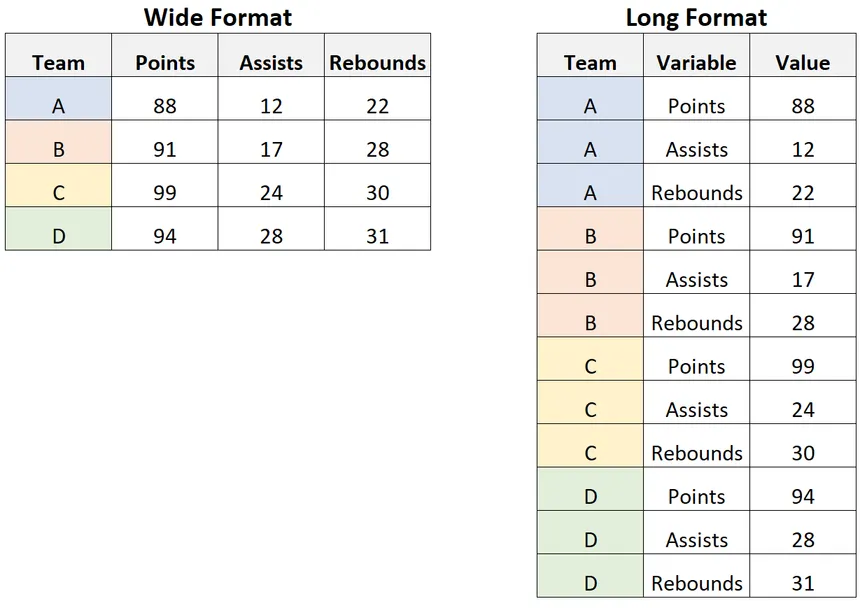

### Wide Format : Single row mein data points honge sare
- Example : (A,B,C and D) ka data 4 rows mein hi aa gaya

### Long Foramt : Har data point ke ke liye utni hi rows hongi jitne column attributes hai
- Example : (A,B,C and D) ke liye utne hi rows ban rahe hai jitne columns hai ( Points, Assists and Rebounds )

# Melt -> converts wide to long data format

# Pivot -> converts long to wide data format

In [28]:
# melt : wide to long DataFrame
df = pd.DataFrame({                            # creating DataFrame with 'branch' , and years columns with the values present in the list
    'branch' : ['cse' , 'ece' , 'mech'],
    '2020'   : [100 , 150 , 60],
    '2021'   : [120 , 130 , 80],
    '2022'   : [150 , 140 , 70]
})

print(df , '\n')                              # printing the created DataFrame
print(df.melt(id_vars = ['branch'] , var_name = 'year' , value_name = 'No. of students'))     # id_vars = ['branch'] -> this stops the 'branch' to repeat in multiple rows
                                                                                              # var_name = ''   -> changes the varaible name
                                                                                              # value_name = '' -> changes the value name

  branch  2020  2021  2022
0    cse   100   120   150
1    ece   150   130   140
2   mech    60    80    70 

  branch  year  No. of students
0    cse  2020              100
1    ece  2020              150
2   mech  2020               60
3    cse  2021              120
4    ece  2021              130
5   mech  2021               80
6    cse  2022              150
7    ece  2022              140
8   mech  2022               70


# Working on real Dataset of covid cases

In [29]:
deaths = pd.read_csv('/content/drive/MyDrive/CSV_files/time_series_covid19_deaths_global.csv')
confirmed_cases = pd.read_csv('/content/drive/MyDrive/CSV_files/time_series_covid19_confirmed_global.csv')

In [30]:
deaths.head()

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,12/24/22,12/25/22,12/26/22,12/27/22,12/28/22,12/29/22,12/30/22,12/31/22,1/1/23,1/2/23
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,7845,7846,7846,7846,7846,7847,7847,7849,7849,7849
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,3595,3595,3595,3595,3595,3595,3595,3595,3595,3595
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,6881,6881,6881,6881,6881,6881,6881,6881,6881,6881
3,NaN,Andorra,42.50630,1.521800,0,0,0,0,0,0,...,165,165,165,165,165,165,165,165,165,165
4,NaN,Angola,-11.20270,17.873900,0,0,0,0,0,0,...,1928,1928,1928,1930,1930,1930,1930,1930,1930,1930


In [31]:
confirmed_cases.head()

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,12/24/22,12/25/22,12/26/22,12/27/22,12/28/22,12/29/22,12/30/22,12/31/22,1/1/23,1/2/23
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,207310,207399,207438,207460,207493,207511,207550,207559,207616,207627
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,333749,333749,333751,333751,333776,333776,333806,333806,333811,333812
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,271194,271198,271198,271202,271208,271217,271223,271228,271229,271229
3,NaN,Andorra,42.50630,1.521800,0,0,0,0,0,0,...,47686,47686,47686,47686,47751,47751,47751,47751,47751,47751
4,NaN,Angola,-11.20270,17.873900,0,0,0,0,0,0,...,104973,104973,104973,105095,105095,105095,105095,105095,105095,105095


## Make a final DataFrame with Country/Region , Date , Total_deaths , Confirmed_cases

In [32]:
# step-1 : melt both the DataFrames and update them in 'deaths' and 'confirmed_cases' DataFrame objects

# deaths DataFrame
deaths = deaths.melt(id_vars = ['Province/State' , 'Country/Region' , 'Lat' , 'Long'] , var_name = 'Date' , value_name = 'Total_deaths')

# confirmed_cases DataFrame
confirmed_cases = confirmed_cases.melt(id_vars = ['Province/State' , 'Country/Region' , 'Lat' , 'Long'] , var_name = 'Date' , value_name = 'Confirmed_cases')

In [33]:
# step-2 : merge both the above DataFrames and take out only desired 'columns'
confirmed_cases.merge(deaths , on = ['Province/State' , 'Country/Region'	, 'Lat' ,	'Long' , 'Date']) [['Country/Region' , 'Date' , 'Total_deaths' , 'Confirmed_cases']]

,Country/Region,Date,Total_deaths,Confirmed_cases
0,Afghanistan,1/22/20,0,0
1,Albania,1/22/20,0,0
2,Algeria,1/22/20,0,0
3,Andorra,1/22/20,0,0
4,Angola,1/22/20,0,0
...,...,...,...,...
311248,West Bank and Gaza,1/2/23,5708,703228
311249,Winter Olympics 2022,1/2/23,0,535
311250,Yemen,1/2/23,2159,11945
311251,Zambia,1/2/23,4024,334661


Pivot Table

- Pivot table takes simple column-wise data and, groups as entries to provide a multi-dimensional summary of the data

In [48]:
import numpy as np
import pandas as pd
import seaborn as sns

### Tips Dataset from seaborn library : People's data who give tips to restro waiters

In [49]:
df = sns.load_dataset('tips')
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [50]:
# fetch out the avg 'male' and 'female' tips who are smokers or not

# Method-1 : using groupby() and unstack() approach
df.groupby(['sex' , 'smoker'] , observed = False)[['total_bill']].mean()


total_bill
sex    smoker            
Male   Yes      22.284500
       No       19.791237
Female Yes      17.977879
       No       18.105185

In [51]:
# Method-2 : fetching same Data using 'pivot_table()' function

df.pivot_table(index = 'sex' , columns = 'smoker' , values = 'total_bill' , observed = False)

# Note : by default 'aggfunc()' does 'mean' of the 'values' wala column

smoker,Yes,No
sex,,
Male,22.284500,19.791237
Female,17.977879,18.105185


aggfunc() : parameter inside pivot_table() function to provide data according to the need

In [55]:
df.pivot_table(index = 'sex' , columns = 'smoker' , values = 'total_bill' , aggfunc = 'count' , observed = False)     # aggfunc() = count -> counts the total number of 'males' and 'females' who smokes or not


# Note : aggfunc() includes -> count , sum , mean , median , standard deviation(std) , variance(var) , Self_made logical functions

smoker,Yes,No
sex,,
Male,1337.07,1919.75
Female,593.27,977.68


### all columns together : performs analysis on all numerical columns

In [62]:
# Example: Aggregating 'total_bill', 'tip', and 'size' (assuming 'size' is numerical)
# Also, explicitly setting observed=False to manage the FutureWarning for categorical 'sex' and 'smoker' columns.

df.pivot_table(index='sex', columns='smoker', values=['total_bill', 'tip', 'size'], observed=False)      # it is a 'DataFrame', hence you can fetch any data using techniques learnt on multi-index DataFrames

size                 tip           total_bill           
smoker       Yes        No       Yes        No        Yes         No
sex                                                                 
Male    2.500000  2.711340  3.051167  3.113402  22.284500  19.791237
Female  2.242424  2.592593  2.931515  2.773519  17.977879  18.105185

### multi-dimensional banana using pivot_table

In [70]:
df.pivot_table(index = ['sex' , 'smoker'] , columns = ['day' , 'time'] , observed = False)

size                                                   tip  \
day                Thur              Fri              Sat       Sun      Thur   
time              Lunch Dinner     Lunch Dinner    Dinner    Dinner     Lunch   
sex    smoker                                                                   
Male   Yes     2.300000    NaN  1.666667    2.4  2.629630  2.600000  3.058000   
       No      2.500000    NaN       NaN    2.0  2.656250  2.883721  2.941500   
Female Yes     2.428571    NaN  2.000000    2.0  2.200000  2.500000  2.990000   
       No      2.500000    2.0  3.000000    2.0  2.307692  3.071429  2.437083   

                                                      total_bill         \
day                    Fri              Sat       Sun       Thur          
time          Dinner Lunch Dinner    Dinner    Dinner      Lunch Dinner   
sex    smoker                                                             
Male   Yes       NaN  1.90  3.246  2.879259  3.521333  19.171000    NaN   
       No        NaN   NaN  2.500  3.256563  3.115349  18.486500    NaN   
Female Yes       NaN  2.66  2.700  2.868667  3.500000  19.218571    NaN   
       No        3.0  3.00  3.250  2.724615  3.329286  15.899167  18.78   

                                                        
day                  Fri                Sat        Sun  
time               Lunch  Dinner     Dinner     Dinner  
sex    smoker                                           
Male   Yes     11.386667  25.892  21.837778  26.141333  
       No            NaN  17.475  19.929063  20.403256  
Female Yes     13.260000  12.200  20.266667  16.540000  
       No      15.980000  22.750  19.003846  20.824286

In [73]:
# aggfunc() function on 'multiple columns' using 'dictionary{}'

df.pivot_table(index = ['sex' , 'smoker'] , columns = ['day' , 'time'] , values = ['size' , 'tip' , 'total_bill'] , aggfunc = {'size' : 'mean' , 'tip' : 'max' , 'total_bill' : 'sum'} , observed = False)

size                                               tip  \
day                Thur              Fri              Sat       Sun  Thur   
time              Lunch Dinner     Lunch Dinner    Dinner    Dinner Lunch   
sex    smoker                                                               
Male   Yes     2.300000    NaN  1.666667    2.4  2.629630  2.600000  5.00   
       No      2.500000    NaN       NaN    2.0  2.656250  2.883721  6.70   
Female Yes     2.428571    NaN  2.000000    2.0  2.200000  2.500000  5.00   
       No      2.500000    2.0  3.000000    2.0  2.307692  3.071429  5.17   

                                                total_bill                \
day                    Fri           Sat    Sun       Thur           Fri   
time          Dinner Lunch Dinner Dinner Dinner      Lunch Dinner  Lunch   
sex    smoker                                                              
Male   Yes       NaN  2.20   4.73  10.00    6.5     191.71   0.00  34.16   
       No        NaN   NaN   3.50   9.00    6.0     369.73   0.00   0.00   
Female Yes       NaN  3.48   4.30   6.50    4.0     134.53   0.00  39.78   
       No        3.0  3.00   3.25   4.67    5.2     381.58  18.78  15.98   

                                                   
day                     Sat           Sun          
time           Dinner Lunch  Dinner Lunch  Dinner  
sex    smoker                                      
Male   Yes     129.46   0.0  589.62   0.0  392.12  
       No       34.95   0.0  637.73   0.0  877.34  
Female Yes      48.80   0.0  304.00   0.0   66.16  
       No       22.75   0.0  247.05   0.0  291.54

### margins : provides the row-wise and column-wise total opf numerical data

In [74]:
df.pivot_table(index = 'sex' , columns = 'smoker' , values = 'total_bill' , aggfunc = 'sum' , margins = True , observed = False)

# Note : 'All' named 'row' and 'column' is the 'total of values' in those rows and columns

smoker,Yes,No,All
sex,,,
Male,1337.07,1919.75,3256.82
Female,593.27,977.68,1570.95
All,1930.34,2897.43,4827.77


### Plotting graph on pivot_table() object using 'expense_csv' dataset

In [76]:
df = pd.read_csv('/content/drive/MyDrive/CSV_files/expense_data.csv')
df

,Date,Account,Category,Subcategory,Note,INR,Income/Expense,Note.1,Amount,Currency,Account.1
0,3/2/2022 10:11,CUB - online payment,Food,NaN,Brownie,50.0,Expense,NaN,50.0,INR,50.0
1,3/2/2022 10:11,CUB - online payment,Other,NaN,To lended people,300.0,Expense,NaN,300.0,INR,300.0
2,3/1/2022 19:50,CUB - online payment,Food,NaN,Dinner,78.0,Expense,NaN,78.0,INR,78.0
3,3/1/2022 18:56,CUB - online payment,Transportation,NaN,Metro,30.0,Expense,NaN,30.0,INR,30.0
4,3/1/2022 18:22,CUB - online payment,Food,NaN,Snacks,67.0,Expense,NaN,67.0,INR,67.0
...,...,...,...,...,...,...,...,...,...,...,...
272,11/22/2021 14:16,CUB - online payment,Food,NaN,Dinner,90.0,Expense,NaN,90.0,INR,90.0
273,11/22/2021 14:16,CUB - online payment,Food,NaN,Lunch with company,97.0,Expense,NaN,97.0,INR,97.0
274,11/21/2021 17:07,CUB - online payment,Transportation,NaN,Rapido,130.0,Expense,NaN,130.0,INR,130.0
275,11/21/2021 15:50,CUB - online payment,Food,NaN,Lunch,875.0,Expense,NaN,875.0,INR,875.0


In [81]:
# Convert the 'Date' column to 'datetime' object first
df['Date'] = pd.to_datetime(df['Date'])    # converting to 'datetime object'
df['Date'].dt.month_name()                 # fetching out month names

,Date
0,March
1,March
2,March
3,March
4,March
...,...
272,November
273,November
274,November
275,November


In [84]:
df['month'] = df['Date'].dt.month_name()   # adding new column as 'month' using month names
df

,Date,Account,Category,Subcategory,Note,INR,Income/Expense,Note.1,Amount,Currency,Account.1,month
0,2022-03-02 10:11:00,CUB - online payment,Food,NaN,Brownie,50.0,Expense,NaN,50.0,INR,50.0,March
1,2022-03-02 10:11:00,CUB - online payment,Other,NaN,To lended people,300.0,Expense,NaN,300.0,INR,300.0,March
2,2022-03-01 19:50:00,CUB - online payment,Food,NaN,Dinner,78.0,Expense,NaN,78.0,INR,78.0,March
3,2022-03-01 18:56:00,CUB - online payment,Transportation,NaN,Metro,30.0,Expense,NaN,30.0,INR,30.0,March
4,2022-03-01 18:22:00,CUB - online payment,Food,NaN,Snacks,67.0,Expense,NaN,67.0,INR,67.0,March
...,...,...,...,...,...,...,...,...,...,...,...,...
272,2021-11-22 14:16:00,CUB - online payment,Food,NaN,Dinner,90.0,Expense,NaN,90.0,INR,90.0,November
273,2021-11-22 14:16:00,CUB - online payment,Food,NaN,Lunch with company,97.0,Expense,NaN,97.0,INR,97.0,November
274,2021-11-21 17:07:00,CUB - online payment,Transportation,NaN,Rapido,130.0,Expense,NaN,130.0,INR,130.0,November
275,2021-11-21 15:50:00,CUB - online payment,Food,NaN,Lunch,875.0,Expense,NaN,875.0,INR,875.0,November


<Axes: xlabel='month'>

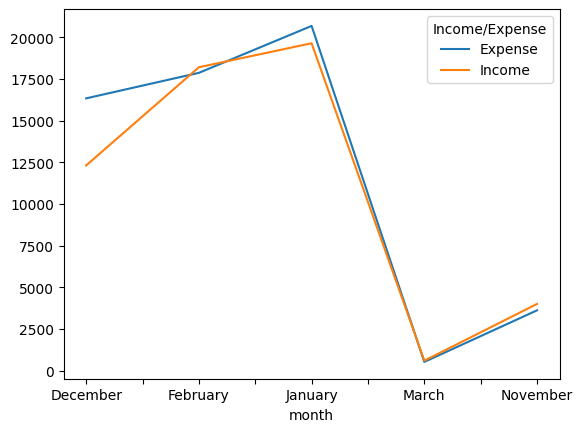

In [99]:
# now use 'pivot_table()' for graph plotting with 'plot(kind = '')'

df.pivot_table(index = 'month' , columns = 'Income/Expense' , values = 'INR' , fill_value = 0 , aggfunc = 'sum').plot(kind = 'line')